In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation

# Inhoud

1. [Introductie en specificaties](#1-introductie-en-specificaties)
2. [Ontwerp van de nokgeometrie](#2-ontwerp-van-de-nokgeometrie)
3. [Inverse dynamica en nokveer](#3-inverse-dynamica-en-nokveer)
4. [Prestaties en verificatie](#4-prestaties-en-verificatie)
5. [Finale ontwerpwaarden en checklist](#5-finale-ontwerpwaarden-en-checklist)
6. [Referenties](#referenties)

<a id="intro"></a>
# 1. Introductie en Specificaties
## 1.1 Nokken-ontwerp: specificaties
Gegevens : De te ontwerpen nok moet volgende heffing kunnen realiseren :

1. van 45° tot 90° : +5 mm
2. van 90° tot 180° : +15 mm
3. van 180° tot 305° : -20 mm

De equivalente massa en dempingsconstante van de volger (en bijhorende onderdelen) worden respectievelijk geschat op 15 kg en 0.055, terwijl het mechanisme volgende statische krachten moet uitoefenen:

1. van 45° tot 90° : een konstante druk-kracht van 250 N
2. van 90° tot 180° : een lineair toenemende druk-kracht van 250 N tot 1050 N
3. van 180° tot 250° : een konstante trek-kracht van 300 N

De gevraagde cyclustijd voor de bewerking uitgevoerd door de volger is 0.3 sec.

Hieronder tonen we de gegeven specs in een grafiek van de positie en de kracht

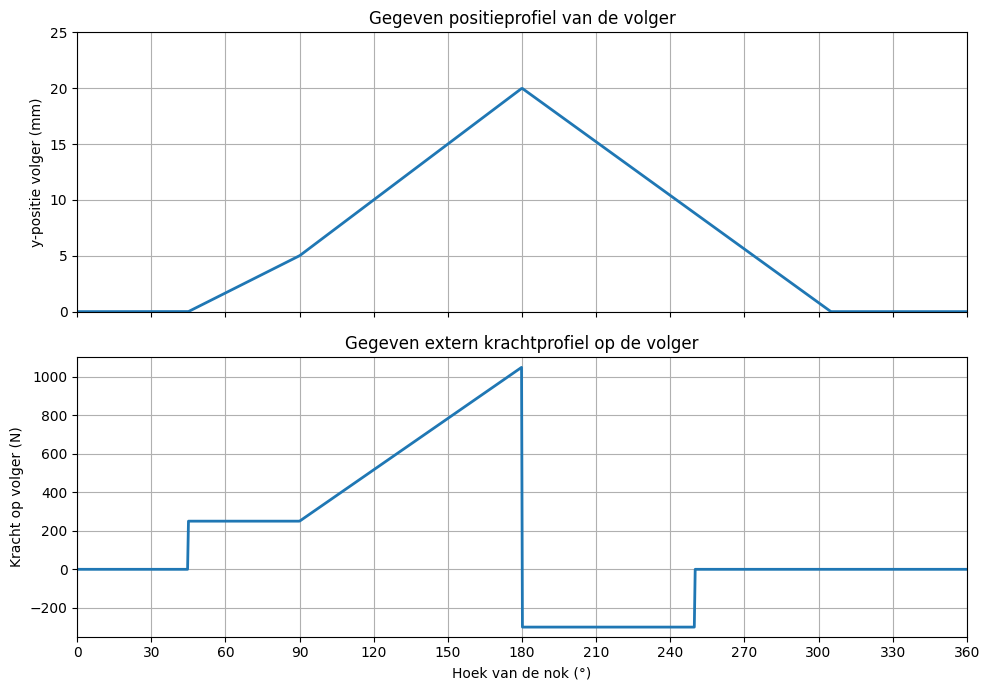

In [2]:
"""
Gegeven specificaties
"""

theta = np.linspace(0, 360, 1000)   # hoek van de nok °

F_pre = 250    #N
F_max = 1050   #N
F_pull = -300  #N

theta_pull_end = 250 #°

"""
Positieprofiel y(theta)
"""
y = np.zeros_like(theta)

# 45°-90°: 0mm - 5mm
mask = (theta >= 45) & (theta < 90)
y[mask] = (theta[mask] - 45) / (90 - 45) * 5

# 90°-180°: 5mm - 20mm
mask = (theta >= 90) & (theta < 180)
y[mask] = 5 + (theta[mask] - 90) / (180 - 90) * 15

# 180°-305°: van 20mm - 0mm
mask = (theta >= 180) & (theta < 305)
y[mask] = 20 - (theta[mask] - 180) / (305 - 180) * 20

# 0°-45° en 305°-360° blijven 0mm

"""
Externe kracht F(theta)
"""
F = np.zeros_like(theta)

# 45° - 90°: cte drukkracht
mask = (theta >= 45) & (theta < 90)
F[mask] = F_pre

# 90° - 180°: lineair stijgend van F_pre naar F_max
mask = (theta >= 90) & (theta < 180)
F[mask] = F_pre + (theta[mask] - 90) / (180 - 90) * (F_max - F_pre)

# 180° - theta_pull_end: cte trekkracht
mask = (theta >= 180) & (theta < theta_pull_end)
F[mask] = F_pull

# Na theta_pull_end blijft de kracht 0 N

"""
# Grafieken
"""
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Grafiek 1: positie
axs[0].plot(theta, y, linewidth=2)
axs[0].set_ylabel("y-positie volger (mm)")
axs[0].set_title("Gegeven positieprofiel van de volger")
axs[0].set_xlim(0, 360)
axs[0].set_ylim(0, 25)
axs[0].set_yticks(np.arange(0, 26, 5))
axs[0].grid(True)

# Grafiek 2: kracht
axs[1].plot(theta, F, linewidth=2)
axs[1].set_xlabel("Hoek van de nok (°)")
axs[1].set_ylabel("Kracht op volger (N)")
axs[1].set_title("Gegeven extern krachtprofiel op de volger")
axs[1].set_xlim(0, 360)
axs[1].set_ylim(-350, 1100)
axs[1].set_xticks(np.arange(0, 361, 30))
axs[1].grid(True)

plt.tight_layout()
plt.show()

# 1.2: Toepassing - Tablet Press

Op basis van het krachtenprofiel dachten we een soort stempelmachine te maken. Dit past goed bij een nokmechanisme, omdat de gewenste beweging periodiek is en omdat de kracht sterk afhankelijk is van de positie van de stempel .Omdat de krachten niet ongelofelijk hoog zijn was de toepassing tablet press voor de farmaseutische industrie boven gekomen. Hieronder is een schets van de verschillende stappen met daaronder uitleg.

<p align="center">
  <img src="Images\visualisatie_compressie.png" width="700"><br>
  <b>Figuur 1:</b> Visualie compressiestappen
</p>

#### Positie 1: Rust
*Hoeken: 305°-45°*

De stempel blijft zijn positie houden en ondervind geen externe krachten. Tijdens deze fase wordt de afgemaakte pil afgevoerd en een nieuwe matrijs gevuld met poeder klaargezet voor de volgende compressie.

#### Positie 2: Plaatsing stempel
*Hoek: $\theta_1$*

De stempel in rust is 2.5mm verwijderd van de opening van de matrijs. Van positie 1 naar positie 2 verplaatst de stempel dus +2.5mm zonder kracht te ondervinden. De reden dat deze hoek $\theta_1$ wordt genoemd is omdat uiteindelijk het verplaatsingsprofiel wordt verzacht om minder sterke schokken te krijgen (deze moet dus berekend worden).

#### Positie 3: Indrukken stempel
*Hoek: 90°*

De stempel positioneert zich 2.5mm in de matrijs (afmaken van 5mm verplaatsing). Binnen de matrijs in de neerwaarste slag zal de stempel een constante tegenwerkende wrijving ([1]) van 250N ondervinden (daarom dat van 1 $\rightarrow$ 3 opgesplitst moest worden). De kleine compressie van de poeder die hier gebeurt wordt verwaarloosd.

#### Positie 4: Compressie + Dwell
*Hoeken: 150°-180°*

Van 90°-150° is de compressieslag van de stempel waar de stempel 15mm in de matrijs wordt geduwd. Compressie wordt gemodelleerd als evenredig met de samendrukking en dus lineair toenemend tot 1050N. Hierbovenop wordt de wrijving in de matrijs gesuperponeerd.

Van 150°-180° blijft de stempel op dezelfde positie. Dit heet dwelling en zorgt ervoor dat er minder kans is op barsten in de pil ([2],[3]). In deze positie ondervind de stempel altijd dezelfde kracht van 1050N.

#### Positie 5: Uittrekken
*Hoek: $\theta_2$*

Van 180°-$\theta_2$ wordt de stempel 17.5mm uitgetrokken. Op deze positie is de stempel net uit de matrijs en tot dan ondervindt het een tegenwerkende kracht van -300N.

#### Positie 6: Terug naar startpositie
*Hoek: 305°*

De stempel verplaatst de laatste 2.5mm terug naar de startpositie. Tijdens deze beweging ondervindt de stempel geen uitwendige kracht.

### Verschillen met gegeven positie- en krachtprofielen:
Ten opzichte van de oorspronkelijke specificatie voegen we dus vooral een duidelijkere compressiefase en een dwell op maximale lift toe. Hierdoor sluit het bewegingsprofiel beter aan bij de gekozen toepassing.

### Vergelijking met commerciele tablet press:
[4], [5], [6]

<div style="display: flex; justify-content: center; margin-top: 1rem;">
    <img src=""
         style="max-width: 600px; width: 100%; height: auto; border: 0;" />
</div>
<div style="display: flex; gap: 25px; align-items: flex-start;">
  <figure style="width: 38%; text-align: center;">
    <img src="Images/Tablet_press_animation.gif" style="width: 100%;">
    <figcaption><b>Figuur:</b> Animatie van compressiestappen commerciele tablet press.</figcaption>
  </figure>

  <figure style="width: 28%; text-align: center;">
    <img src="Images\pill-maker-machine.webp" style="width: 100%;">
    <figcaption><b>Figuur:</b> Foto commerciele tablet press.</figcaption>
  </figure>
</div>


<a id="referenties"></a>
# 6. Referenties

[1] Research article die wall friction: https://www.sciencedirect.com/science/article/pii/0032591083870090?fr=RR-2&ref=pdf_download&rr=a0f3901e18301327

[2] Krachten bij tablet compressie: https://www.scribd.com/document/879454686/Various-Forces-in-the-Compression

[3] Tablet compression force: https://www.futek.com/applications/pill-press-force-verification

[4] How tablet compression works: https://www.abbviecontractmfg.com/news-and-insights/fun-science-friday/tableting-vs-encapsulation.html

[5] Voorbeeld tablet copression machine: https://nl.achievechem.com/tablet-press-machines/pill-maker-machine.html

[6] Gif tablet compressie nokkenband: https://en.wikipedia.org/wiki/File:Tablet_press_animation.gif
